<a href="https://colab.research.google.com/github/amany2712/project_nlp/blob/machine_learning_models/project_nlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import nltk

# NLP
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

# ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Models
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# DL
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    Dense,
    Dropout,
    Conv1D,
    GlobalMaxPooling1D,
    LSTM
)

from tensorflow.keras.callbacks import EarlyStopping

In [15]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [9]:
url_data = "https://raw.githubusercontent.com/amany2712/project_nlp/refs/heads/main/spam_email_dataset.csv"
df = pd.read_csv(url_data)
df.head(100)

,email_id,subject,email_text,num_words,num_characters,num_exclamation_marks,num_links,has_suspicious_link,num_attachments,has_attachment,sender_email,sender_domain,sender_reputation_score,email_hour,email_day_of_week,is_weekend,num_recipients,contains_money_terms,contains_urgency_terms,label
0,0,Weekly Report,budget review - Statement our I claim world st...,19,114,0,2,0,2,1,lctvdzm@outlook.com,outlook.com,0.66,19,3,0,23,0,0,0
1,1,Project Update,team sync - President series today already. In...,18,114,0,7,0,0,0,pxyldmi@company.com,company.com,0.95,4,4,0,16,1,0,0
2,2,🔥WIN BIG NOW!!,win free urgent offer limited limited urgent u...,19,126,0,4,1,1,1,atvanls@unknownmail.cc,unknownmail.cc,0.68,3,0,0,10,1,1,1
3,3,🔥WIN BIG NOW!!,guarantee click now cash offer click now guara...,16,101,0,7,1,1,1,qalxcnf@chealdealz.xyz,chealdealz.xyz,0.69,19,5,1,25,1,1,1
4,4,Meeting Reminder,team sync - Significant property hotel not add...,18,111,0,7,1,2,1,xoiccxl@yahoo.com,yahoo.com,0.67,4,5,1,8,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,95,Schedule Confirmation,budget review - Turn sea understand guess. Pic...,15,105,0,4,0,0,0,jkjzdcs@outlook.com,outlook.com,0.82,0,1,0,7,0,0,0
96,96,Limited Offer!!!,offer cash click now offer offer free Nice ind...,15,90,0,4,1,1,1,zamhcmh@freemoney.biz,freemoney.biz,0.32,21,2,0,6,1,1,1
97,97,Weekly Report,budget review - Seat whose professor machine t...,19,133,0,6,1,1,1,rczgcbu@company.com,company.com,0.56,19,3,0,16,0,1,0
98,98,🔥WIN BIG NOW!!,guarantee limited win urgent win click now urg...,14,90,0,0,0,0,0,btqnwew@chealdealz.xyz,chealdealz.xyz,0.40,6,0,0,3,1,1,1


In [10]:
df.isnull().sum()

,0
email_id,0
subject,0
email_text,0
num_words,0
num_characters,0
num_exclamation_marks,0
num_links,0
has_suspicious_link,0
num_attachments,0
has_attachment,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   email_id                 10000 non-null  int64  
 1   subject                  10000 non-null  object 
 2   email_text               10000 non-null  object 
 3   num_words                10000 non-null  int64  
 4   num_characters           10000 non-null  int64  
 5   num_exclamation_marks    10000 non-null  int64  
 6   num_links                10000 non-null  int64  
 7   has_suspicious_link      10000 non-null  int64  
 8   num_attachments          10000 non-null  int64  
 9   has_attachment           10000 non-null  int64  
 10  sender_email             10000 non-null  object 
 11  sender_domain            10000 non-null  object 
 12  sender_reputation_score  10000 non-null  float64
 13  email_hour               10000 non-null  int64  
 14  email_day_of_week      

In [12]:
df=df.drop(columns=['email_id', 'sender_email'])

In [13]:
df.duplicated().sum()

np.int64(0)

In [16]:
print(df['label'].unique())

[0 1]


In [17]:
from scipy.sparse import hstack, csr_matrix
#Create Stemmer + Stopwords
ps= PorterStemmer()
stop = set(stopwords.words('english'))

def clean_text(text):
    #If the text is empty
    if pd.isna(text): return ''

    # lowercase
    text = str(text).lower()

    # remove URLs
    text = re.sub(r'http\S+', '', text)

    # remove email addresses
    text = re.sub(r'\S+@\S+', '', text)

    #remove symbols & numbers
    text = re.sub(r'[^a-z\s]', '', text)

    tokens = word_tokenize(text)
    tokens = [
    ps.stem(w)
    for w in tokens
    if w not in stop
    and len(w) > 2
    ]
    return ' '.join(tokens)

df['combined_text'] = (df['subject'].fillna('') + ' ' +
                        df['email_text'].fillna('')).apply(clean_text)

print("finish...")
print(df['combined_text'].head(3))

finish...
0    weekli report budget review statement claim wo...
1    project updat team sync presid seri today alre...
2    win big win free urgent offer limit limit urge...
Name: combined_text, dtype: object


In [18]:
df

,subject,email_text,num_words,num_characters,num_exclamation_marks,num_links,has_suspicious_link,num_attachments,has_attachment,sender_domain,sender_reputation_score,email_hour,email_day_of_week,is_weekend,num_recipients,contains_money_terms,contains_urgency_terms,label,combined_text
0,Weekly Report,budget review - Statement our I claim world st...,19,114,0,2,0,2,1,outlook.com,0.66,19,3,0,23,0,0,0,weekli report budget review statement claim wo...
1,Project Update,team sync - President series today already. In...,18,114,0,7,0,0,0,company.com,0.95,4,4,0,16,1,0,0,project updat team sync presid seri today alre...
2,🔥WIN BIG NOW!!,win free urgent offer limited limited urgent u...,19,126,0,4,1,1,1,unknownmail.cc,0.68,3,0,0,10,1,1,1,win big win free urgent offer limit limit urge...
3,🔥WIN BIG NOW!!,guarantee click now cash offer click now guara...,16,101,0,7,1,1,1,chealdealz.xyz,0.69,19,5,1,25,1,1,1,win big guarante click cash offer click guaran...
4,Meeting Reminder,team sync - Significant property hotel not add...,18,111,0,7,1,2,1,yahoo.com,0.67,4,5,1,8,0,0,0,meet remind team sync signific properti hotel ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,🔥WIN BIG NOW!!,free win cash win guarantee urgent free win li...,22,136,0,5,1,0,0,unknownmail.cc,0.68,8,1,0,29,1,1,1,win big free win cash win guarante urgent free...
9996,You are selected!!!,click now free guarantee free win click now wi...,26,158,0,2,0,0,0,chealdealz.xyz,0.76,2,3,0,29,0,1,1,select click free guarante free win click win ...
9997,You are selected!!!,offer cash win limited click now cash limited ...,21,124,0,3,1,1,1,unknownmail.cc,0.69,6,1,0,25,0,1,1,select offer cash win limit click cash limit c...
9998,Meeting Reminder,budget review - Many result affect idea.,7,40,0,1,0,2,1,outlook.com,0.80,7,2,0,18,0,0,0,meet remind budget review mani result affect idea


In [19]:
num_cols = ['num_words','num_characters','num_exclamation_marks',
            'num_links','has_suspicious_link','num_attachments',
            'has_attachment','sender_reputation_score','email_hour',
            'email_day_of_week','is_weekend','num_recipients',
            'contains_money_terms','contains_urgency_terms']

X_tr_txt, X_te_txt, y_train, y_test = train_test_split(
    df['combined_text'], df['label'],
    test_size=0.2, random_state=42
)

X_tr_num = df.loc[X_tr_txt.index, num_cols]
X_te_num = df.loc[X_te_txt.index, num_cols]

print("Train size:", len(X_tr_txt))
print("Test size: ", len(X_te_txt))

Train size: 8000
Test size:  2000


In [23]:
# TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X_tr_tfidf = tfidf.fit_transform(X_tr_txt)
X_te_tfidf = tfidf.transform(X_te_txt)

# MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_tr_num_sc = csr_matrix(scaler.fit_transform(X_tr_num))
X_te_num_sc = csr_matrix(scaler.transform(X_te_num))

# Merge
X_train = hstack([X_tr_tfidf, X_tr_num_sc])
X_test  = hstack([X_te_tfidf, X_te_num_sc])

print("ready!")
print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)

ready!
X_train shape: (8000, 863)
X_test shape:  (2000, 863)


Naive Bayes (ML)

In [24]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

MultinomialNB()

In [25]:
nb_pred = nb_model.predict(X_test)

In [33]:
print("Naive Bayes Results")

print("Accuracy :", accuracy_score(y_test, nb_pred))

print("Precision:", precision_score(y_test, nb_pred))

print("Recall   :", recall_score(y_test, nb_pred))

print("F1 Score :", f1_score(y_test, nb_pred))

Naive Bayes Results
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [27]:
print(df['label'].value_counts(normalize=True))

label
0    0.6005
1    0.3995
Name: proportion, dtype: float64


In [28]:
print(confusion_matrix(y_test, nb_pred))

[[1181    0]
 [   0  819]]


Logistic Regression

In [34]:
lr_model = LogisticRegression(
    max_iter=3000
)

lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=3000)

In [35]:
lr_pred = lr_model.predict(X_test)

In [36]:
print("Logistic Regression Results")

print("Accuracy :", accuracy_score(y_test, lr_pred))

print("Precision:", precision_score(y_test, lr_pred))

print("Recall   :", recall_score(y_test, lr_pred))

print("F1 Score :", f1_score(y_test, lr_pred))

Logistic Regression Results
Accuracy : 0.9995
Precision: 1.0
Recall   : 0.9987789987789988
F1 Score : 0.9993891264508247


In [37]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1181
           1       1.00      1.00      1.00       819

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



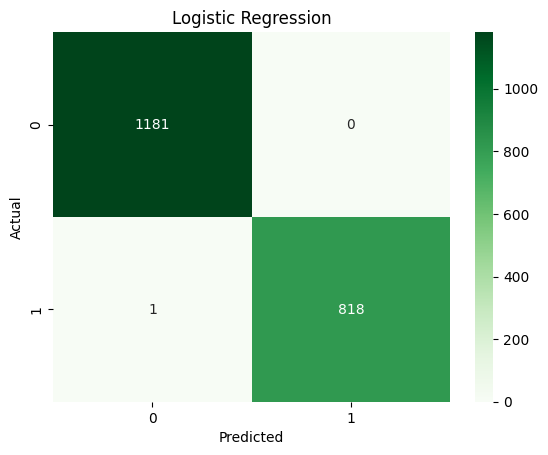

In [38]:
cm = confusion_matrix(y_test, lr_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Logistic Regression")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()